In [1]:
!pip install -q transformers datasets evaluate peft accelerate sentencepiece bitsandbytes bert_score

In [2]:
import torch
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    TrainingArguments,
    Trainer,
    DataCollatorForSeq2Seq
)
from peft import LoraConfig, get_peft_model
import evaluate

In [3]:
dataset = load_dataset("paws", "labeled_final")

train_raw = dataset["train"].filter(lambda x: x["label"] == 1)
val_raw = dataset["validation"].filter(lambda x: x["label"] == 1)

# Select manageable subset
train_raw = train_raw.shuffle(seed=42).select(range(20000))
val_raw = val_raw.select(range(1000))

print("Train size:", len(train_raw))

Train size: 20000


In [4]:
model_name = "google/flan-t5-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [5]:
def preprocess(example):
    input_text = f"Paraphrase: {example['sentence1']}"
    target_text = example["sentence2"]

    model_inputs = tokenizer(
        input_text,
        max_length=64,
        truncation=True
    )

    labels = tokenizer(
        target_text,
        max_length=64,
        truncation=True
    )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

train_dataset = train_raw.map(preprocess, remove_columns=train_raw.column_names)
val_dataset = val_raw.map(preprocess, remove_columns=val_raw.column_names)

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [6]:
import evaluate

bleu = evaluate.load("bleu")
rouge = evaluate.load("rouge")
bertscore = evaluate.load("bertscore")

In [7]:
def evaluate_model(model, model_name):
    print(f"\nEvaluating {model_name} model...")
    model.eval()
    
    predictions = []
    references = []

    for example in val_raw.select(range(200)):
        input_text = f"Paraphrase: {example['sentence1']}"
        reference = example["sentence2"]

        inputs = tokenizer(
            input_text,
            return_tensors="pt",
            truncation=True
        ).to("cuda")

        with torch.no_grad():
            outputs = model.generate(**inputs, max_length=64)

        pred = tokenizer.decode(outputs[0], skip_special_tokens=True)

        predictions.append(pred)
        references.append(reference)

    # ---------------- BLEU ----------------
    bleu_score = bleu.compute(
        predictions=predictions,
        references=[[r] for r in references]
    )["bleu"]

    # ---------------- ROUGE ----------------
    rouge_scores = rouge.compute(
        predictions=predictions,
        references=references
    )

    # ---------------- BERTScore ----------------
    bert_scores = bertscore.compute(
        predictions=predictions,
        references=references,
        lang="en"
    )

    avg_bert_f1 = sum(bert_scores["f1"]) / len(bert_scores["f1"])

    # ---------------- Print Results ----------------
    print("\n============================")
    print(f"{model_name} BLEU Score      : {bleu_score*100:.2f}")
    print(f"{model_name} ROUGE-1        : {rouge_scores['rouge1']*100:.2f}")
    print(f"{model_name} ROUGE-2        : {rouge_scores['rouge2']*100:.2f}")
    print(f"{model_name} ROUGE-L        : {rouge_scores['rougeL']*100:.2f}")
    print(f"{model_name} BERTScore (F1) : {avg_bert_f1*100:.2f}")
    print("============================\n")

    return {
        "bleu": bleu_score,
        "rouge1": rouge_scores["rouge1"],
        "rouge2": rouge_scores["rouge2"],
        "rougeL": rouge_scores["rougeL"],
        "bertscore_f1": avg_bert_f1
    }

In [8]:
baseline_model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to("cuda")

print("BASELINE RESULTS")
evaluate_model(baseline_model, "BASELINE")

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


BASELINE RESULTS

Evaluating BASELINE model...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



BASELINE BLEU Score      : 43.53
BASELINE ROUGE-1        : 77.43
BASELINE ROUGE-2        : 58.29
BASELINE ROUGE-L        : 68.74
BASELINE BERTScore (F1) : 95.00



{'bleu': 0.43529341239598496,
 'rouge1': np.float64(0.7743060172870124),
 'rouge2': np.float64(0.5829443221645056),
 'rougeL': np.float64(0.6873520055592186),
 'bertscore_f1': 0.9499866405129432}

In [9]:
import time

fft_model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to("cuda")

training_args = TrainingArguments(
    output_dir="./fft_results",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    learning_rate=2e-4,
    fp16=True,
    logging_steps=200,
    save_strategy="no",
    report_to="none"
)

trainer = Trainer(
    model=fft_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=DataCollatorForSeq2Seq(tokenizer, model=fft_model),
)


start_time_fft = time.time()

trainer.train()


end_time_fft = time.time()

fft_training_time = end_time_fft - start_time_fft

print(f"\nFFT Training Time: {fft_training_time/60:.2f} minutes")

print("FFT RESULTS")
fft_bleu = evaluate_model(fft_model, "FFT")

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Step,Training Loss
200,1.130296
400,1.054643
600,1.014611
800,0.954546
1000,0.933274
1200,0.932396
1400,0.796776
1600,0.752920
1800,0.756405
2000,0.748082



FFT Training Time: 30.90 minutes
FFT RESULTS

Evaluating FFT model...

FFT BLEU Score      : 64.68
FFT ROUGE-1        : 92.87
FFT ROUGE-2        : 75.63
FFT ROUGE-L        : 84.22
FFT BERTScore (F1) : 97.61



In [10]:
# ---- Parameter Statistics for FFT ----

total_params = sum(p.numel() for p in fft_model.parameters())
trainable_params = sum(p.numel() for p in fft_model.parameters() if p.requires_grad)

print("\n============================")
print("FULL FINE-TUNING PARAMETER STATS")
print("============================")
print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")
print(f"Trainable Percentage : {100 * trainable_params / total_params:.2f}%")
print("============================\n")


FULL FINE-TUNING PARAMETER STATS
Total Parameters     : 247,577,856
Trainable Parameters : 247,577,856
Trainable Percentage : 100.00%



In [11]:
from peft import LoraConfig, get_peft_model

In [12]:
from accelerate.state import AcceleratorState
AcceleratorState._reset_state()

In [13]:
import time

#  Reset accelerate 
from accelerate.state import AcceleratorState
from accelerate import PartialState

AcceleratorState._reset_state()
_ = PartialState()

#  Reload base model 
lora_model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to("cuda")

from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=64,
    lora_alpha=128,
    target_modules=["q", "v"],
    lora_dropout=0.05,
    bias="none",
    task_type="SEQ_2_SEQ_LM"
)

lora_model = get_peft_model(lora_model, lora_config)

training_args_lora = TrainingArguments(
    output_dir="./lora_results",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    learning_rate=3e-4,
    fp16=True,
    logging_steps=200,
    save_strategy="no",
    report_to="none"
)

trainer_lora = Trainer(
    model=lora_model,
    args=training_args_lora,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=DataCollatorForSeq2Seq(tokenizer, model=lora_model),
)


start_time_lora = time.time()

trainer_lora.train()


end_time_lora = time.time()

lora_training_time = end_time_lora - start_time_lora

print(f"\nLoRA Training Time: {lora_training_time/60:.2f} minutes")

print("LORA RESULTS")
lora_bleu = evaluate_model(lora_model, "LoRA")

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Step,Training Loss
200,1.201554
400,1.116540
600,1.084542
800,1.045368
1000,1.030084
1200,1.030084
1400,1.000818
1600,0.975177
1800,0.973399
2000,0.955595



LoRA Training Time: 27.40 minutes
LORA RESULTS

Evaluating LoRA model...

LoRA BLEU Score      : 63.36
LoRA ROUGE-1        : 92.87
LoRA ROUGE-2        : 74.57
LoRA ROUGE-L        : 83.57
LoRA BERTScore (F1) : 97.56



In [14]:
#  Parameter Statistics for LoRA 

total_params_lora = sum(p.numel() for p in lora_model.parameters())
trainable_params_lora = sum(p.numel() for p in lora_model.parameters() if p.requires_grad)

print("\n============================")
print("LORA PARAMETER STATS")
print("============================")
print(f"Total Parameters     : {total_params_lora:,}")
print(f"Trainable Parameters : {trainable_params_lora:,}")
print(f"Trainable Percentage : {100 * trainable_params_lora / total_params_lora:.2f}%")
print("============================\n")


LORA PARAMETER STATS
Total Parameters     : 254,655,744
Trainable Parameters : 7,077,888
Trainable Percentage : 2.78%



In [15]:
import random

def print_sample_outputs(num_samples=5):
    print("\n" + "="*80)
    print("QUALITATIVE SAMPLE COMPARISON")
    print("="*80)

    indices = random.sample(range(len(val_raw)), num_samples)

    for i, idx in enumerate(indices, 1):
        example = val_raw[idx]

        input_text = f"Paraphrase: {example['sentence1']}"
        reference = example["sentence2"]

        inputs = tokenizer(input_text, return_tensors="pt", truncation=True).to("cuda")

        with torch.no_grad():
            baseline_out = baseline_model.generate(**inputs, max_length=64)
            fft_out = fft_model.generate(**inputs, max_length=64)
            lora_out = lora_model.generate(**inputs, max_length=64)

        baseline_pred = tokenizer.decode(baseline_out[0], skip_special_tokens=True)
        fft_pred = tokenizer.decode(fft_out[0], skip_special_tokens=True)
        lora_pred = tokenizer.decode(lora_out[0], skip_special_tokens=True)

        print(f"\n----- SAMPLE {i} ----")
        print("INPUT:")
        print(example["sentence1"])
        print("\nREFERENCE:")
        print(reference)
        print("\nBASELINE OUTPUT:")
        print(baseline_pred)
        print("\nFFT OUTPUT:")
        print(fft_pred)
        print("\nLORA OUTPUT:")
        print(lora_pred)
        print("-"*80)

print_sample_outputs(10)


QUALITATIVE SAMPLE COMPARISON

---------------- SAMPLE 1 ----------------
INPUT:
Peter DuConge ( 1903 -1967 ) was an early jazz reedist , active in the American New Orleans jazz scene .

REFERENCE:
Peter DuConge ( 1903 - 1967 ) was an early Jazz - Reedist , active in the American jazz scene in New Orleans .

BASELINE OUTPUT:
Peter DuConge was an early jazz reedist , active in the American New Orleans jazz scene .

FFT OUTPUT:
Peter DuConge ( 1903 -- 1967 ) was an early jazz reedist active in the American New Orleans jazz scene .

LORA OUTPUT:
Peter DuConge ( 1903 -- 1967 ) was an early jazz reedist , active in the American New Orleans jazz scene .
--------------------------------------------------------------------------------

---------------- SAMPLE 2 ----------------
INPUT:
Katz was born in Sweden in 1947 and moved to New York City at the age of 1 .

REFERENCE:
Katz was born in 1947 in Sweden and moved to New York at the age of one .

BASELINE OUTPUT:
Katz was born in Sweden in 194

In [16]:
import matplotlib.pyplot as plt

In [17]:
import matplotlib.pyplot as plt

# Extract loss history
def extract_loss(trainer):
    losses = []
    steps = []
    for log in trainer.state.log_history:
        if "loss" in log and "epoch" in log:
            losses.append(log["loss"])
            steps.append(log["step"])
    return steps, losses

fft_steps, fft_losses = extract_loss(trainer)
lora_steps, lora_losses = extract_loss(trainer_lora)

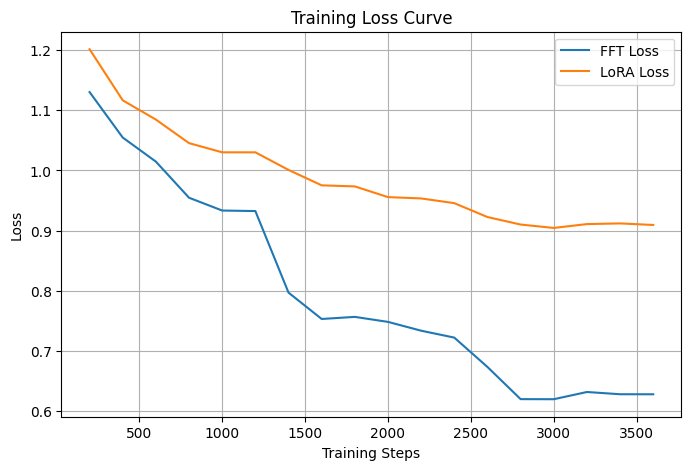

In [18]:
plt.figure(figsize=(8,5))

plt.plot(fft_steps, fft_losses, label="FFT Loss")
plt.plot(lora_steps, lora_losses, label="LoRA Loss")

plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
baseline_results = evaluate_model(baseline_model, "Baseline")
fft_results = evaluate_model(fft_model, "FFT")
lora_results = evaluate_model(lora_model, "LoRA")


Evaluating Baseline model...

Baseline BLEU Score      : 43.53
Baseline ROUGE-1        : 77.43
Baseline ROUGE-2        : 58.29
Baseline ROUGE-L        : 68.74
Baseline BERTScore (F1) : 95.00


Evaluating FFT model...

FFT BLEU Score      : 64.68
FFT ROUGE-1        : 92.87
FFT ROUGE-2        : 75.63
FFT ROUGE-L        : 84.22
FFT BERTScore (F1) : 97.61


Evaluating LoRA model...

LoRA BLEU Score      : 63.36
LoRA ROUGE-1        : 92.87
LoRA ROUGE-2        : 74.57
LoRA ROUGE-L        : 83.57
LoRA BERTScore (F1) : 97.56



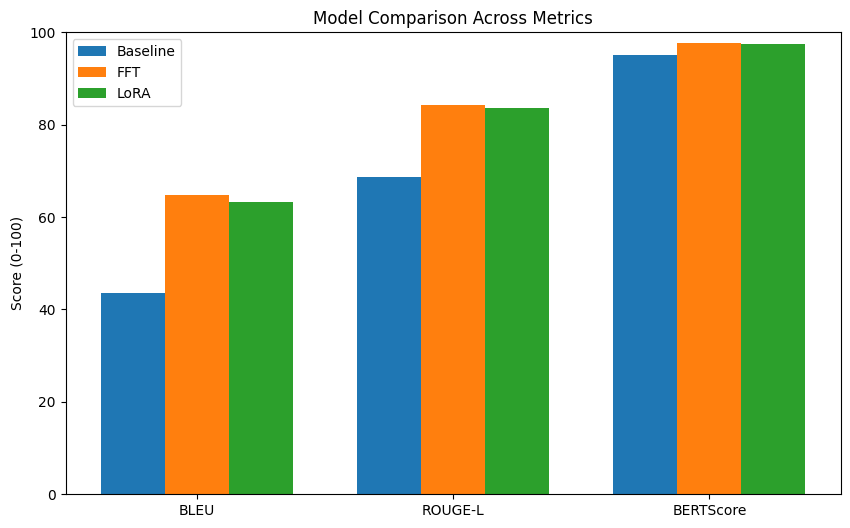

In [20]:
import numpy as np
import matplotlib.pyplot as plt

metrics = ["BLEU", "ROUGE-L", "BERTScore"]

baseline_vals = [
    baseline_results["bleu"] * 100,
    baseline_results["rougeL"] * 100,
    baseline_results["bertscore_f1"] * 100
]

fft_vals = [
    fft_results["bleu"] * 100,
    fft_results["rougeL"] * 100,
    fft_results["bertscore_f1"] * 100
]

lora_vals = [
    lora_results["bleu"] * 100,
    lora_results["rougeL"] * 100,
    lora_results["bertscore_f1"] * 100
]

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(10,6))
plt.bar(x - width, baseline_vals, width, label="Baseline")
plt.bar(x, fft_vals, width, label="FFT")
plt.bar(x + width, lora_vals, width, label="LoRA")

plt.xticks(x, metrics)
plt.ylim(0, 100)
plt.ylabel("Score (0-100)")
plt.title("Model Comparison Across Metrics")
plt.legend()
plt.show()

In [22]:
import torch
import psutil
import platform

print("\n" + "="*80)
print("FINAL EXPERIMENT REPORT")
print("="*80)

# METRIC COMPARISON

print("\nEVALUATION METRICS")
print("-"*60)

print(f"{'Model':<10} {'BLEU':>10} {'ROUGE-L':>12} {'BERTScore':>15}")
print("-"*60)

print(f"{'Baseline':<10} "
      f"{baseline_results['bleu']*100:>9.2f} "
      f"{baseline_results['rougeL']*100:>11.2f} "
      f"{baseline_results['bertscore_f1']*100:>14.2f}")

print(f"{'FFT':<10} "
      f"{fft_results['bleu']*100:>9.2f} "
      f"{fft_results['rougeL']*100:>11.2f} "
      f"{fft_results['bertscore_f1']*100:>14.2f}")

print(f"{'LoRA':<10} "
      f"{lora_results['bleu']*100:>9.2f} "
      f"{lora_results['rougeL']*100:>11.2f} "
      f"{lora_results['bertscore_f1']*100:>14.2f}")

# Parameter Statistics

def param_stats(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable, 100 * trainable / total

fft_total, fft_trainable, fft_pct = param_stats(fft_model)
lora_total, lora_trainable, lora_pct = param_stats(lora_model)

print("\nPARAMETER STATISTICS")
print("-"*60)
print(f"FFT  -> {fft_trainable:,} / {fft_total:,} ({fft_pct:.4f}% trainable)")
print(f"LoRA -> {lora_trainable:,} / {lora_total:,} ({lora_pct:.4f}% trainable)")

# Training Time

print("\nTRAINING TIME")
print("-"*60)
print(f"FFT Training Time  : {fft_training_time/60:.2f} minutes")
print(f"LoRA Training Time : {lora_training_time/60:.2f} minutes")


# System Information

print("\nSYSTEM INFORMATION")
print("-"*60)
print("OS           :", platform.system())
print("CPU          :", platform.processor())
print("CPU Cores    :", psutil.cpu_count())
print("RAM (GB)     :", round(psutil.virtual_memory().total / (1024**3), 2))

if torch.cuda.is_available():
    print("GPU          :", torch.cuda.get_device_name(0))
    print("CUDA Version :", torch.version.cuda)
    print("Total VRAM   :", round(torch.cuda.get_device_properties(0).total_memory / (1024**3), 2), "GB")
    print("Used VRAM    :", round(torch.cuda.memory_allocated(0) / (1024**3), 2), "GB")
else:
    print("GPU          : Not Available")

print("="*80)


FINAL EXPERIMENT REPORT

EVALUATION METRICS
------------------------------------------------------------
Model            BLEU      ROUGE-L       BERTScore
------------------------------------------------------------
Baseline       43.53       68.74          95.00
FFT            64.68       84.22          97.61
LoRA           63.36       83.57          97.56

PARAMETER STATISTICS
------------------------------------------------------------
FFT  -> 247,577,856 / 247,577,856 (100.0000% trainable)
LoRA -> 7,077,888 / 254,655,744 (2.7794% trainable)

TRAINING TIME
------------------------------------------------------------
FFT Training Time  : 30.90 minutes
LoRA Training Time : 27.40 minutes

SYSTEM INFORMATION
------------------------------------------------------------
OS           : Linux
CPU          : x86_64
CPU Cores    : 4
RAM (GB)     : 31.35
GPU          : Tesla T4
CUDA Version : 12.6
Total VRAM   : 14.56 GB
Used VRAM    : 5.74 GB
